In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load cleaned train and test data
train_data = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_data.csv")
test_data  = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_data.csv")

print(f"Train rows: {len(train_data)}")
print(f"Test rows:  {len(test_data)}")
print(f"Columns:    {len(train_data.columns)}")
print("\nColumn list:")
print(list(train_data.columns))

Train rows: 49703
Test rows:  12024
Columns:    30

Column list:
['ViewYN', 'PoolPrivateYN', 'OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'CountyOrParish', 'AttachedGarageYN', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'City', 'BedroomsTotal', 'FireplaceYN', 'Stories', 'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode', 'AssociationFee', 'LotSizeSquareFeet', 'CloseMonth', 'City_encoded', 'PostalCode_encoded', 'CountyOrParish_encoded', 'HighSchoolDistrict_encoded']


In [3]:
# Feature Engineering 
# 1. Property Age
train_data["PropertyAge"] = 2025 - train_data["YearBuilt"]
test_data["PropertyAge"]  = 2025 - test_data["YearBuilt"]

# 2. Bed/Bath Ratio
# Replace 0 bathrooms with 1 to avoid division by zero
train_data["BedBathRatio"] = (
    train_data["BedroomsTotal"] / train_data["BathroomsTotalInteger"].replace(0, 1)
)
test_data["BedBathRatio"] = (
    test_data["BedroomsTotal"] / test_data["BathroomsTotalInteger"].replace(0, 1)
)

# 3. Total Rooms bedrooms + bathrooms combined
train_data["TotalRooms"] = train_data["BedroomsTotal"] + train_data["BathroomsTotalInteger"]
test_data["TotalRooms"]  = test_data["BedroomsTotal"]  + test_data["BathroomsTotalInteger"]

# 4. Living Area per Bedroom
train_data["AreaPerBedroom"] = (
    train_data["LivingArea"] / train_data["BedroomsTotal"].replace(0, 1)
)
test_data["AreaPerBedroom"] = (
    test_data["LivingArea"] / test_data["BedroomsTotal"].replace(0, 1)
)

# 5. Has HOA flag
train_data["HasHOA"] = (train_data["AssociationFee"] > 0).astype(int)
test_data["HasHOA"]  = (test_data["AssociationFee"]  > 0).astype(int)

# 6. Lot to Living Area Ratio
train_data["LotLivingRatio"] = (
    train_data["LotSizeSquareFeet"] / train_data["LivingArea"].replace(0, 1)
)
test_data["LotLivingRatio"] = (
    test_data["LotSizeSquareFeet"] / test_data["LivingArea"].replace(0, 1)
)

# Confirm new features
new_features = ["PropertyAge", "BedBathRatio", "TotalRooms", 
                "AreaPerBedroom", "HasHOA", "LotLivingRatio"]

print("New features created:")
print(train_data[new_features].describe().round(2))
print(f"\nTotal columns now: {len(train_data.columns)}")

New features created:
       PropertyAge  BedBathRatio  TotalRooms  AreaPerBedroom    HasHOA  \
count     49703.00      49703.00    49703.00        49703.00  49703.00   
mean         48.66          1.45        6.13          581.65      0.26   
std          27.71          0.48        1.92          199.70      0.44   
min          -1.00          0.00        0.00            0.00      0.00   
25%          26.00          1.00        5.00          446.80      0.00   
50%          48.00          1.50        6.00          542.86      0.00   
75%          69.00          1.50        7.00          668.00      1.00   
max         224.00          6.00       40.00         3000.00      1.00   

       LotLivingRatio  
count        49703.00  
mean           504.56  
std          61298.71  
min              0.00  
25%              2.97  
50%              4.20  
75%              6.02  
max       13481820.00  

Total columns now: 36


In [4]:
#Two issues to fix:
#1. PropertyAge min = -1 — means at least one property has YearBuilt = 2026, which is a future date, likely a data entry error. We'll cap it at 0.
#2. LotLivingRatio max = 13,481,820 — extreme outlier, probably a property with a massive lot but tiny house. We'll cap it.

# Cap PropertyAge at 0 minimum — no negative ages
train_data["PropertyAge"] = train_data["PropertyAge"].clip(lower=0)
test_data["PropertyAge"]  = test_data["PropertyAge"].clip(lower=0)

# Cap LotLivingRatio at 99th percentile to remove extreme outliers
lot_cap = train_data["LotLivingRatio"].quantile(0.99)
train_data["LotLivingRatio"] = train_data["LotLivingRatio"].clip(upper=lot_cap)
test_data["LotLivingRatio"]  = test_data["LotLivingRatio"].clip(upper=lot_cap)

# Confirm fixes
print("PropertyAge min after fix:", train_data["PropertyAge"].min())
print("LotLivingRatio max after fix:", train_data["LotLivingRatio"].max().round(2))
print("\nPropertyAge distribution:")
print(train_data["PropertyAge"].describe().round(2))

PropertyAge min after fix: 0.0
LotLivingRatio max after fix: 170.08

PropertyAge distribution:
count    49703.00
mean        48.67
std         27.70
min          0.00
25%         26.00
50%         48.00
75%         69.00
max        224.00
Name: PropertyAge, dtype: float64


In [4]:
import urllib.request
import os
import geopandas as gpd

# Load the school district boundaries
school_districts = gpd.read_file(
    r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\ca_school_districts.geojson"
)

print(f"Total school districts loaded: {len(school_districts)}")
print(f"\nColumns: {list(school_districts.columns)}")
print(f"\nSample DistrictType values:")
print(school_districts["DistrictType"].value_counts().head(10))

Total school districts loaded: 936

Columns: ['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']

Sample DistrictType values:
DistrictType
Elementary    515
Unified       345
High           76
Name: count, dtype: int64


In [5]:
# Filter to Unified school districts only
unified = school_districts[school_districts["DistrictType"] == "Unified"].copy()

print(f"Total districts: {len(school_districts)}")
print(f"Unified districts only: {len(unified)}")
print(f"\nSample unified district names:")
print(unified["DistrictName"].head(10).tolist())# Step 4 — Filter to Unified school districts only
unified = school_districts[school_districts["DistrictType"] == "Unified"].copy()

print(f"Total districts: {len(school_districts)}")
print(f"Unified districts only: {len(unified)}")
print(f"\nSample unified district names:")
print(unified["DistrictName"].head(10).tolist())

Total districts: 936
Unified districts only: 345

Sample unified district names:
['Alameda Unified', 'Albany City Unified', 'Berkeley Unified', 'Castro Valley Unified', 'Emery Unified', 'Fremont Unified', 'Hayward Unified', 'Livermore Valley Joint Unified', 'Newark Unified', 'New Haven Unified']
Total districts: 936
Unified districts only: 345

Sample unified district names:
['Alameda Unified', 'Albany City Unified', 'Berkeley Unified', 'Castro Valley Unified', 'Emery Unified', 'Fremont Unified', 'Hayward Unified', 'Livermore Valley Joint Unified', 'Newark Unified', 'New Haven Unified']


In [6]:
from shapely.geometry import Point

# Convert each property's lat/lon into a geographic point
# Do this for both train and test

train_geo = gpd.GeoDataFrame(
    train_data,
    geometry=gpd.points_from_xy(train_data["Longitude"], train_data["Latitude"]),
    crs="EPSG:4326"  # standard lat/lon coordinate system
)

test_geo = gpd.GeoDataFrame(
    test_data,
    geometry=gpd.points_from_xy(test_data["Longitude"], test_data["Latitude"]),
    crs="EPSG:4326"
)

# Make sure unified districts use same coordinate system
unified = unified.to_crs("EPSG:4326")

print(f"Train GeoDataFrame: {len(train_geo)} rows")
print(f"Test GeoDataFrame:  {len(test_geo)} rows")
print(f"\nSample geometry points:")
print(train_geo["geometry"].head(5))

Train GeoDataFrame: 49703 rows
Test GeoDataFrame:  12024 rows

Sample geometry points:
0    POINT (-122.02987 37.87193)
1    POINT (-118.58065 34.15068)
2    POINT (-121.83543 37.30641)
3    POINT (-121.92135 37.27264)
4    POINT (-121.93542 37.30394)
Name: geometry, dtype: geometry


In [7]:
# Spatial join: match each property to its Unified School District
train_joined = gpd.sjoin(
    train_geo,
    unified[["DistrictName", "geometry"]],
    how="left",
    predicate="within"
)

test_joined = gpd.sjoin(
    test_geo,
    unified[["DistrictName", "geometry"]],
    how="left",
    predicate="within"
)

# Check how many properties were matched
train_matched   = train_joined["DistrictName"].notna().sum()
train_unmatched = train_joined["DistrictName"].isna().sum()

test_matched   = test_joined["DistrictName"].notna().sum()
test_unmatched = test_joined["DistrictName"].isna().sum()

print(f"Train matched:   {train_matched} / {len(train_joined)}")
print(f"Train unmatched: {train_unmatched}")
print(f"Train match rate: {train_matched/len(train_joined)*100:.1f}%")
print()
print(f"Test matched:   {test_matched} / {len(test_joined)}")
print(f"Test unmatched: {test_unmatched}")
print(f"Test match rate: {test_matched/len(test_joined)*100:.1f}%")
print()
print("Sample matched properties:")
print(train_joined[["City", "Latitude", "Longitude", "DistrictName"]].dropna().head(10).to_string())

Train matched:   37753 / 49703
Train unmatched: 11950
Train match rate: 76.0%

Test matched:   9057 / 12024
Test unmatched: 2967
Test match rate: 75.3%

Sample matched properties:
              City   Latitude   Longitude              DistrictName
0     Walnut Creek  37.871927 -122.029871  San Ramon Valley Unified
1   Woodland Hills  34.150680 -118.580650       Los Angeles Unified
5    Mission Viejo  33.626544 -117.634791        Capistrano Unified
6          Concord  37.984530 -122.020961        Mt. Diablo Unified
7         Temecula  33.466321 -117.066776   Temecula Valley Unified
8    San Francisco  37.708564 -122.436143     San Francisco Unified
9     Laguna Beach  33.538775 -117.779450      Laguna Beach Unified
10        Mariposa  37.488220 -119.968061   Mariposa County Unified
11         Concord  37.956828 -121.941638        Mt. Diablo Unified
12        Martinez  37.983487 -122.104153        Mt. Diablo Unified


In [9]:
# Add DistrictName as new column
# Fill unmatched properties with "Unknown"
train_data["UnifiedDistrict"] = train_joined["DistrictName"].fillna("Unknown").values
test_data["UnifiedDistrict"]  = test_joined["DistrictName"].fillna("Unknown").values

# Encode the new district column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Fit on train, transform both
le.fit(train_data["UnifiedDistrict"])
train_data["UnifiedDistrict_encoded"] = le.transform(train_data["UnifiedDistrict"])

# Handle unseen labels in test set
test_data["UnifiedDistrict_encoded"] = test_data["UnifiedDistrict"].apply(
    lambda x: le.transform([x])[0] if x in le.classes_ else -1
)

print(f"Unique districts in train: {train_data['UnifiedDistrict'].nunique()}")
print(f"Unique districts in test:  {test_data['UnifiedDistrict'].nunique()}")
print(f"\nTop 10 most common districts in train:")
print(train_data["UnifiedDistrict"].value_counts().head(10))

Unique districts in train: 299
Unique districts in test:  268

Top 10 most common districts in train:
UnifiedDistrict
Unknown                 11950
Los Angeles Unified      4989
San Diego Unified        1416
Desert Sands Unified     1060
Capistrano Unified        960
Palm Springs Unified      916
Oakland Unified           624
Corona-Norco Unified      616
Long Beach Unified        602
Hemet Unified             595
Name: count, dtype: int64


In [10]:
# Save enriched datasets
train_enriched_path = r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_enriched.csv"
test_enriched_path  = r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_enriched.csv"

train_data.to_csv(train_enriched_path, index=False)
test_data.to_csv(test_enriched_path, index=False)

print("Saved successfully!")
print(f"Train shape: {train_data.shape}")
print(f"Test shape:  {test_data.shape}")
print(f"\nNew columns added this week:")
new_cols = ["PropertyAge", "BedBathRatio", "TotalRooms", 
            "AreaPerBedroom", "HasHOA", "LotLivingRatio",
            "UnifiedDistrict", "UnifiedDistrict_encoded"]
print(new_cols)

Saved successfully!
Train shape: (49703, 38)
Test shape:  (12024, 38)

New columns added this week:
['PropertyAge', 'BedBathRatio', 'TotalRooms', 'AreaPerBedroom', 'HasHOA', 'LotLivingRatio', 'UnifiedDistrict', 'UnifiedDistrict_encoded']


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Old feature set (same as Week 5)
old_features = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "Stories",
    "GarageSpaces", "ParkingTotal",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "DaysOnMarket", "AssociationFee",
    "Latitude", "Longitude",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded",
]

# New feature set — old + engineered features
new_features = old_features + [
    "PropertyAge", "BedBathRatio", "TotalRooms",
    "AreaPerBedroom", "HasHOA", "LotLivingRatio",
    "UnifiedDistrict_encoded",
]

print(f"Old feature set: {len(old_features)} features")
print(f"New feature set: {len(new_features)} features")
print(f"New features added: {len(new_features) - len(old_features)}")

Old feature set: 21 features
New feature set: 28 features
New features added: 7


In [12]:
# Remove price outliers — same as before
price_mask_train = (train_data["ClosePrice"] >= 100_000) & (train_data["ClosePrice"] <= 10_000_000)
price_mask_test  = (test_data["ClosePrice"]  >= 100_000) & (test_data["ClosePrice"]  <= 10_000_000)

train_clean = train_data[price_mask_train].copy()
test_clean  = test_data[price_mask_test].copy()

print(f"Train rows after outlier removal: {len(train_clean)}")
print(f"Test rows after outlier removal:  {len(test_clean)}")

Train rows after outlier removal: 49441
Test rows after outlier removal:  11965


In [13]:
results = {}

for name, features in [("Old Features", old_features), ("New Features", new_features)]:
    X_train = train_clean[features]
    y_train = train_clean["ClosePrice"]
    X_test  = test_clean[features]
    y_test  = test_clean["ClosePrice"]

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {"R2": round(r2, 4), "MAE": round(mae, 0)}
    print(f"\n{name}:")
    print(f"  R² Score:            {r2:.4f}")
    print(f"  Mean Absolute Error: ${mae:,.0f}")

# Summary table
print("\n" + "=" * 50)
print("FEATURE SET COMPARISON")
print("=" * 50)
comparison = pd.DataFrame(results).T
print(comparison.to_string())


Old Features:
  R² Score:            0.8567
  Mean Absolute Error: $186,986

New Features:
  R² Score:            0.8532
  Mean Absolute Error: $189,198

FEATURE SET COMPARISON
                  R2       MAE
Old Features  0.8567  186986.0
New Features  0.8532  189198.0


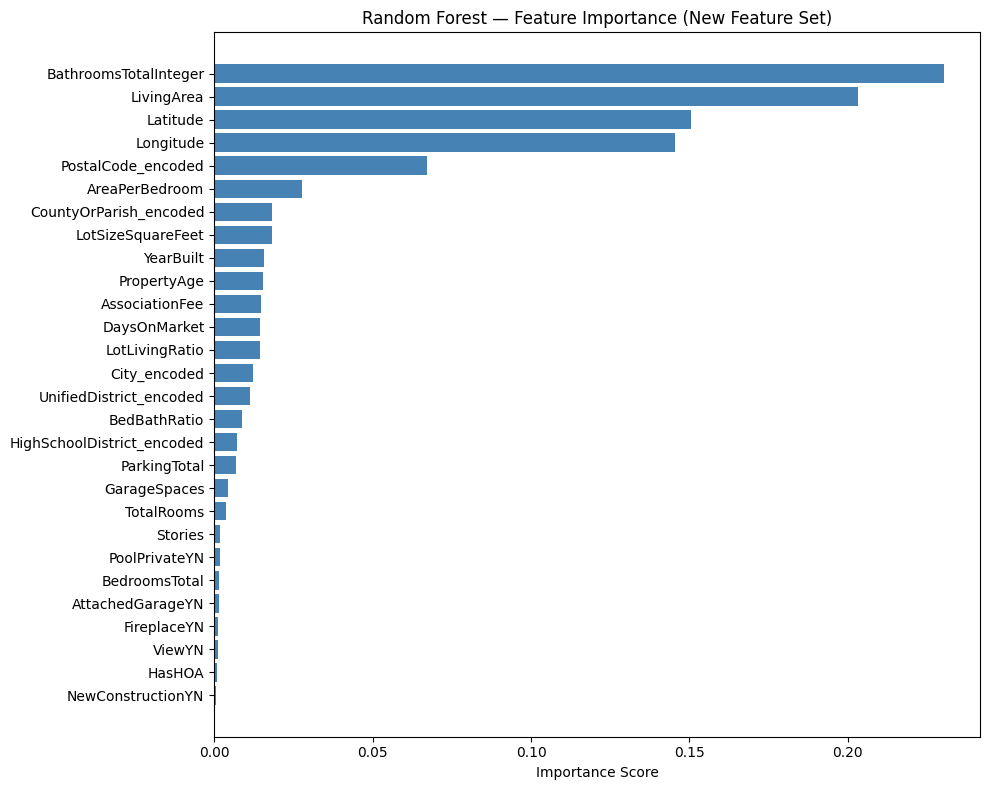


Top 10 most important features:
               Feature  Importance
 BathroomsTotalInteger    0.230194
            LivingArea    0.203084
              Latitude    0.150574
             Longitude    0.145394
    PostalCode_encoded    0.067092
        AreaPerBedroom    0.027600
CountyOrParish_encoded    0.018336
     LotSizeSquareFeet    0.018090
             YearBuilt    0.015841
           PropertyAge    0.015314


In [15]:
# Retrain new features model to get importance
model_new = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_new.fit(train_clean[new_features], train_clean["ClosePrice"])

importance = pd.DataFrame({
    "Feature": new_features,
    "Importance": model_new.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importance (New Feature Set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importance.head(10).to_string(index=False))